### Flexibility design problem

This problem considers a set of demands $I = \{1,2,\ldots,n\}$ and a set of resources $J = \{1,2,\ldots,m\}$. The decisions of the problem consist of assigning resources to cover specific demands (or projects) and determining what proportion of each demand, denoted by $d_i$, is satisfied.

Let $y_{ij}$, for $i \in I$ and $j \in J$, be a binary variable equal to 1 if resource $j$ is assigned to demand $i$, and 0 otherwise, with an associated cost $c_{ij}$. The amount of demand of type $i$ covered by resource $j$ is represented by the nonnegative continuous variable $x_{ij}$, for $i \in I$ and $j \in J$. Resource availability is limited by the capacity $k_j$ of each resource, and the profit obtained from covering demand $i$ with resource $j$ is denoted by $\pi_{ij}$.

The problem can be formulated as follows:

$$
\begin{aligned}
\max \quad & -\sum_{i \in I}\sum_{j \in J} y_{ij} c_{ij} + \sum_{i \in I}\sum_{j \in J} x_{ij} \pi_{ij} \\
\text{s.t.} \quad & \sum_{i \in I} x_{ij} \leq k_j \quad \forall j \in J \\
& \sum_{j \in J} x_{ij} \leq d_i \quad \forall i \in I \\
& x_{ij} \leq y_{ij} \quad \forall i \in I,\; j \in J
\end{aligned}
$$

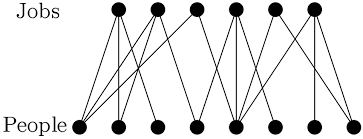

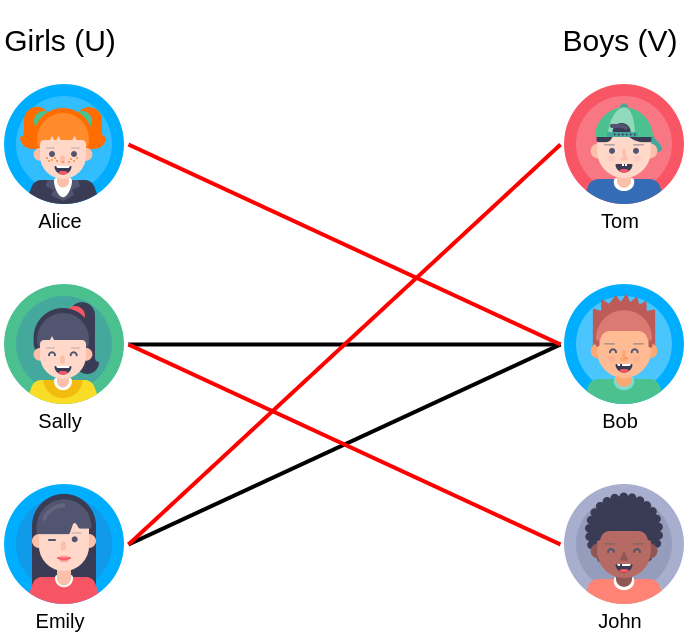

In [ ]:
%pip install -q amplpy numpy matplotlib pandas networkx folium
from amplpy import AMPL, ampl_notebook
import numpy as np

# HiGHS is the default. Gurobi requires an AMPL-compatible license.
SOLVER = "highs"  # or "gurobi"
LICENSE_UUID = "default"  # Colab Community Edition; use your UUID locally
runtime = ampl_notebook(modules=[SOLVER], license_uuid=LICENSE_UUID)

def new_ampl():
    return AMPL()

def solve_checked(model):
    model.solve(solver=SOLVER)
    if model.solve_result != "solved":
        raise RuntimeError(f"No proven optimal solution: {model.solve_result}. "
                           "Inspect the solver log before extracting values.")

def values(model, name):
    # Numeric dictionaries keep plotting independent of the solver API.
    return model.var[name].get_values().to_dict()




In [ ]:
def generate_instance(m, n, profit_cost_ratio=5, seed=None):
    if seed is not None:
        np.random.seed(seed)

    I = list(range(m))
    J = list(range(n))

    d = {i: np.random.uniform(50, 150) for i in I}
    avg_capacity = (n * 100) / m
    K = {j: np.random.uniform(0.7 * avg_capacity, 1.3 * avg_capacity) for j in J}
    c = {(i, j): np.random.uniform(150, 300) for i in I for j in J}
    pi = {(i, j): np.random.uniform(150 / profit_cost_ratio, 300 / profit_cost_ratio) for i in I for j in J}

    return I, J, d, K, c, pi

In [ ]:
def solve_model(I, J, d, K, c, pi):
    model = new_ampl()
    model.eval(r"""
    set I;
    set J;
    param d {I} >= 0;
    param K {J} >= 0;
    param c {I,J};
    param pi {I,J};
    var x {I,J} >= 0;
    var y {I,J} binary;
    maximize Total_Cost: sum {i in I,j in J} (pi[i,j]*x[i,j] - c[i,j]*y[i,j]);
    subject to Capacity {j in J}: sum {i in I} x[i,j] <= K[j];
    subject to Demand {i in I}: sum {j in J} x[i,j] <= d[i];
    subject to Link {i in I,j in J}: x[i,j] <= K[j]*y[i,j];
    """)
    model.set["I"] = list(I)
    model.set["J"] = list(J)
    model.param["d"] = d
    model.param["K"] = K
    model.param["c"] = c
    model.param["pi"] = pi
    
    solve_checked(model)
    x = values(model, "x")
    y = values(model, "y")
    return model, x, y


In [ ]:
I, J, d, K, c, pi = generate_instance(m=5, n=5, profit_cost_ratio=20, seed=42)
model, x, y = solve_model(I, J, d, K, c, pi)


In [ ]:
for i in I:
    for j in J:
        if y[i, j] > 0.5:
            print(f"y[{i},{j}] = 1, x[{i},{j}] = {x[i,j]:.2f}")

print(f"Objective value: {model.obj['Total_Cost'].value():.2f}")


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
G = nx.Graph()
G.add_nodes_from([f"I{i}" for i in I], bipartite=0)
G.add_nodes_from([f"J{j}" for j in J], bipartite=1)

edges = []
labels = {}
for i in I:
    for j in J:
        if y[i, j] > 0.5:
            from_node = f"I{i}"
            to_node = f"J{j}"
            edges.append((from_node, to_node))
            labels[(from_node, to_node)] = f"{x[i,j]:.1f}"

G.add_edges_from(edges)
pos = {**{f"I{i}": (0, -i) for i in I}, **{f"J{j}": (1, -j) for j in J}}

plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1200, font_size=10)
#nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_color='red')
plt.title("Assign which resources to which demands")
plt.axis('off')
plt.tight_layout()
plt.show()

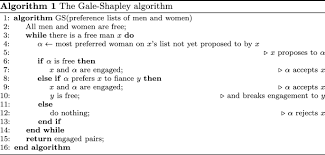